In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load training dataset
data_path = Path("../data/copperbelt_training_v5_with_tectonic_domain.csv")
if not data_path.exists():
    data_path = Path(r"c:\Users\vanmu\copperbelt-mineral-prospectivity\data\copperbelt_training_v5_with_tectonic_domain.csv")

df = pd.read_csv(data_path)
print("Loaded training data:", df.shape)
df.head()

Loaded training data: (1899, 11)


,id,litho_contact_litho_class,distance_to_lithology_contact,deposit_present,bouguer,isostatic,centroid_x,centroid_y,emag,distance_to_fault,domain
0,4825,4,0.000000,0,-15.61,-12.12,529911.7136,8502459.846,-15.411892,62016.776588,Inverted Basid 5 SRB
1,4826,14,2628.229476,0,-15.57,-12.28,529382.7965,8499678.944,-17.954336,64297.817688,LP/LT CRZ 4b
2,4827,14,2628.229476,0,-14.17,-11.06,529694.5101,8496492.719,-18.093077,66320.469142,LP/LT CRZ 4b
3,4922,4,0.000000,0,-13.84,-10.50,533039.8464,8502729.511,-20.726257,59547.010668,LP/LT CRZ 4b
4,4923,4,0.000000,0,-12.58,-9.44,532640.0118,8499799.981,-22.135218,61896.079609,LP/LT CRZ 4b


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1899 entries, 0 to 1898
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             1899 non-null   int64  
 1   litho_contact_litho_class      1899 non-null   int64  
 2   distance_to_lithology_contact  1899 non-null   float64
 3   deposit_present                1899 non-null   int64  
 4   bouguer                        1899 non-null   float64
 5   isostatic                      1899 non-null   float64
 6   centroid_x                     1899 non-null   float64
 7   centroid_y                     1899 non-null   float64
 8   emag                           1899 non-null   float64
 9   distance_to_fault              1899 non-null   float64
 10  domain                         1872 non-null   object 
dtypes: float64(7), int64(3), object(1)
memory usage: 163.3+ KB


In [3]:
df.deposit_present.value_counts()

deposit_present
0    1760
1     139
Name: count, dtype: int64

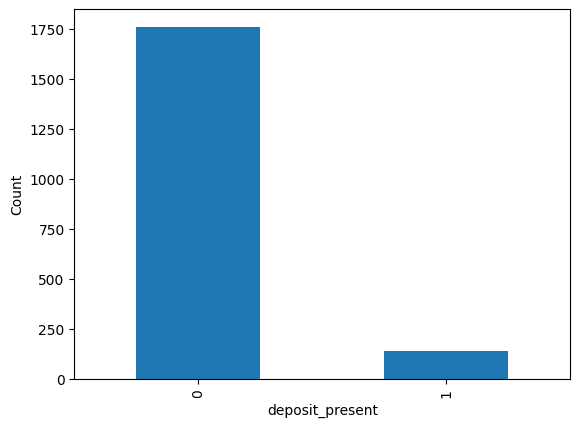

In [4]:
import matplotlib.pyplot as plt

df.deposit_present.value_counts().plot.bar()

plt.ylabel("Count")
plt.show()

In [5]:
missing = df.isna().sum()

missing[missing > 0]

domain    27
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1899.0,4.967361e+03,1.987687e+03,1.700000e+01,3.509500e+03,5.586000e+03,6.459500e+03,8.500000e+03
litho_contact_litho_class,1899.0,9.485519e+00,6.567167e+00,4.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01,2.000000e+01
distance_to_lithology_contact,1899.0,1.407913e+04,1.438084e+04,0.000000e+00,1.919123e+03,9.564394e+03,2.158633e+04,6.985767e+04
deposit_present,1899.0,7.319642e-02,2.605272e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
bouguer,1899.0,-1.719671e+01,1.394255e+01,-5.508000e+01,-2.596500e+01,-1.755000e+01,-8.175000e+00,1.744000e+01
isostatic,1899.0,-7.754676e+00,1.502540e+01,-4.506000e+01,-1.763000e+01,-8.590000e+00,1.700000e+00,3.120000e+01
centroid_x,1899.0,5.365854e+05,1.013216e+05,2.826748e+05,4.629012e+05,5.678573e+05,6.125938e+05,7.154648e+05
centroid_y,1899.0,8.661860e+06,1.379015e+05,8.380251e+06,8.539906e+06,8.694391e+06,8.785657e+06,8.859512e+06
emag,1899.0,-1.467568e+38,1.685709e+38,-3.402823e+38,-3.402823e+38,-4.906081e+01,-7.574942e+00,1.058396e+02
distance_to_fault,1899.0,2.321006e+04,2.506860e+04,1.340049e+00,3.120751e+03,1.455617e+04,3.517674e+04,1.127508e+05


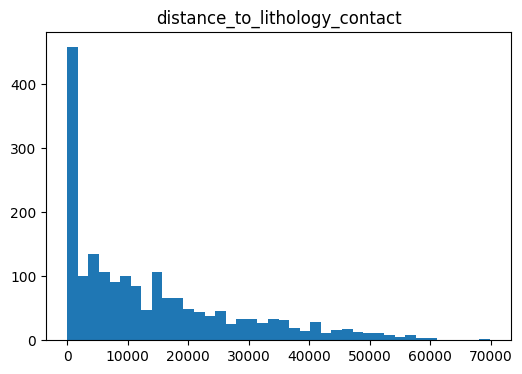

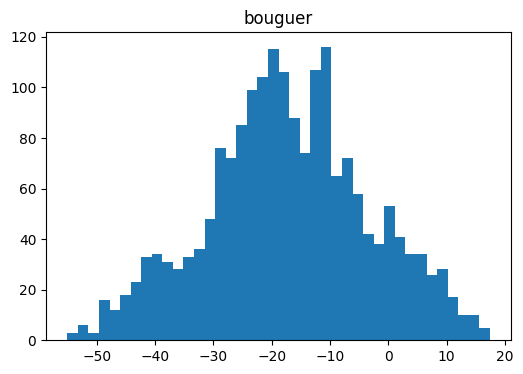

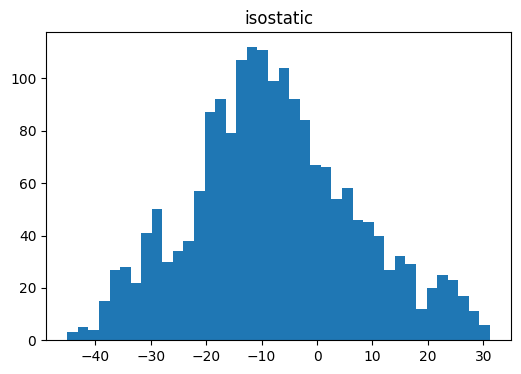

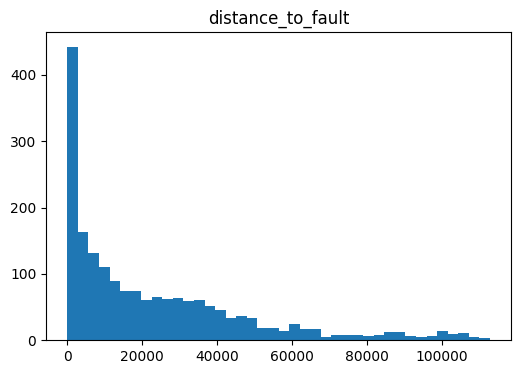

In [7]:
continuous = [
    "distance_to_lithology_contact",
    "bouguer",
    "isostatic",
    "distance_to_fault"
]
for col in continuous:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=40)

    plt.title(col)

    plt.show()

<Figure size 600x400 with 0 Axes>

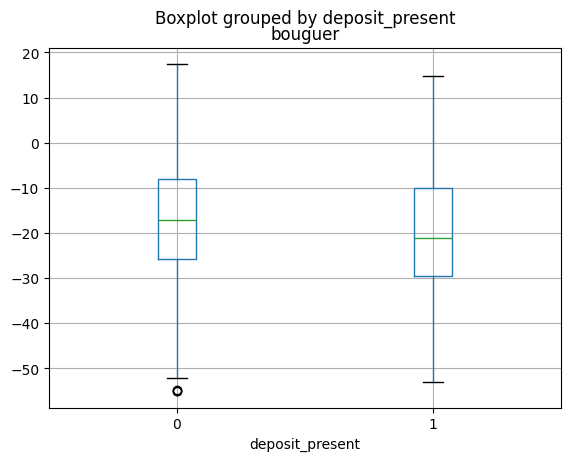

In [8]:
plt.figure(figsize=(6,4))

df.boxplot(
    column="bouguer",
    by="deposit_present"
)

plt.show()

In [9]:
pd.crosstab(
    df.litho_contact_litho_class,
    df.deposit_present
)

deposit_present,0,1
litho_contact_litho_class,,
4,821,70
6,79,6
7,225,14
14,83,0
16,215,14
20,337,35


In [10]:
numeric = [
    "distance_to_lithology_contact",
    "bouguer",
    "isostatic",
    "distance_to_fault"
]

corr = df[numeric].corr()

corr

,distance_to_lithology_contact,bouguer,isostatic,distance_to_fault
distance_to_lithology_contact,1.000000,0.246085,0.320883,-0.206524
bouguer,0.246085,1.000000,0.892456,0.083810
isostatic,0.320883,0.892456,1.000000,-0.210181
distance_to_fault,-0.206524,0.083810,-0.210181,1.000000


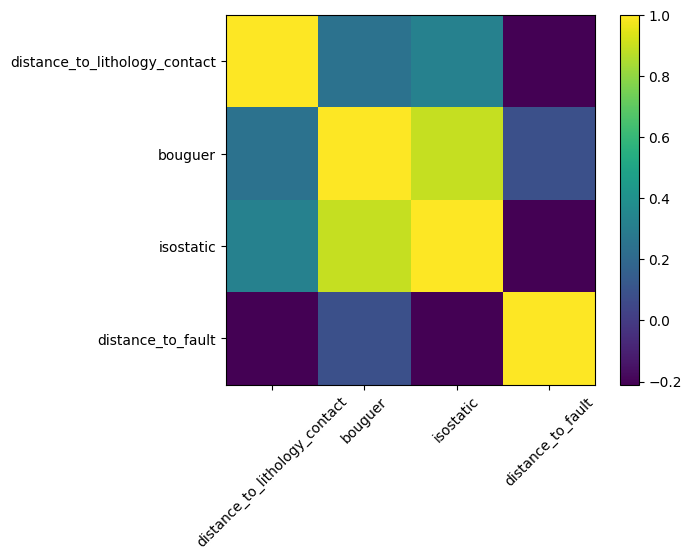

In [11]:
plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.show()

## Binned Distance Analysis: Deposits per Range of Distance

This section analyzes the distribution of mineral deposits (`deposit_present == 1`) across standardized distance intervals (in km) for both:
1. **Distance to Major Faults** (`distance_to_fault`)
2. **Distance to Lithological Contacts** (`distance_to_lithology_contact`)

In [12]:
# 1. Ensure dependencies and data are loaded
import pandas as pd
import numpy as np
from pathlib import Path

if 'df' not in globals() or df is None:
    data_path = Path("../data/copperbelt_training_v5_with_tectonic_domain.csv")
    if not data_path.exists():
        data_path = Path(r"c:\Users\vanmu\copperbelt-mineral-prospectivity\data\copperbelt_training_v5_with_tectonic_domain.csv")
    df = pd.read_csv(data_path)

# Convert distances from metres to kilometres
df['fault_km'] = df['distance_to_fault'] / 1000.0
df['lith_km'] = df['distance_to_lithology_contact'] / 1000.0

# 2. Define standard 5 km distance bins
fault_bins = np.arange(0, 85, 5)
fault_labels = [f'{i}-{i+5}' for i in fault_bins[:-1]]

lith_bins = np.arange(0, 60, 5)
lith_labels = [f'{i}-{i+5}' for i in lith_bins[:-1]]

df['fault_range_km'] = pd.cut(df['fault_km'], bins=fault_bins, labels=fault_labels, right=False)
df['lith_range_km'] = pd.cut(df['lith_km'], bins=lith_bins, labels=lith_labels, right=False)

# 3. Compute bin statistics (deposits vs non-deposits)
fault_binned = df.groupby('fault_range_km', observed=False).agg(
    deposits=('deposit_present', 'sum'),
    non_deposits=('deposit_present', lambda x: (x == 0).sum()),
    total_cells=('deposit_present', 'count')
).reset_index()
fault_binned['deposit_rate_pct'] = (fault_binned['deposits'] / fault_binned['total_cells']) * 100

lith_binned = df.groupby('lith_range_km', observed=False).agg(
    deposits=('deposit_present', 'sum'),
    non_deposits=('deposit_present', lambda x: (x == 0).sum()),
    total_cells=('deposit_present', 'count')
).reset_index()
lith_binned['deposit_rate_pct'] = (lith_binned['deposits'] / lith_binned['total_cells']) * 100

print("=== Fault Distance Bins (0-80 km in 5 km intervals) ===")
display(fault_binned.head(10))

print("\n=== Lithology Contact Distance Bins (0-55 km in 5 km intervals) ===")
display(lith_binned.head(10))

=== Fault Distance Bins (0-80 km in 5 km intervals) ===


,fault_range_km,deposits,non_deposits,total_cells,deposit_rate_pct
0,0-5,78,505,583,13.379074
1,5-10,19,200,219,8.675799
2,10-15,5,156,161,3.105590
3,15-20,9,118,127,7.086614
4,20-25,5,106,111,4.504505
5,25-30,5,110,115,4.347826
6,30-35,2,103,105,1.904762
7,35-40,2,96,98,2.040816
8,40-45,2,69,71,2.816901
9,45-50,1,64,65,1.538462



=== Lithology Contact Distance Bins (0-55 km in 5 km intervals) ===


,lith_range_km,deposits,non_deposits,total_cells,deposit_rate_pct
0,0-5,68,603,671,10.134128
1,5-10,21,274,295,7.118644
2,10-15,15,208,223,6.726457
3,15-20,16,181,197,8.121827
4,20-25,2,122,124,1.612903
5,25-30,0,95,95,0.000000
6,30-35,3,88,91,3.296703
7,35-40,0,60,60,0.000000
8,40-45,3,46,49,6.122449
9,45-50,5,38,43,11.627907


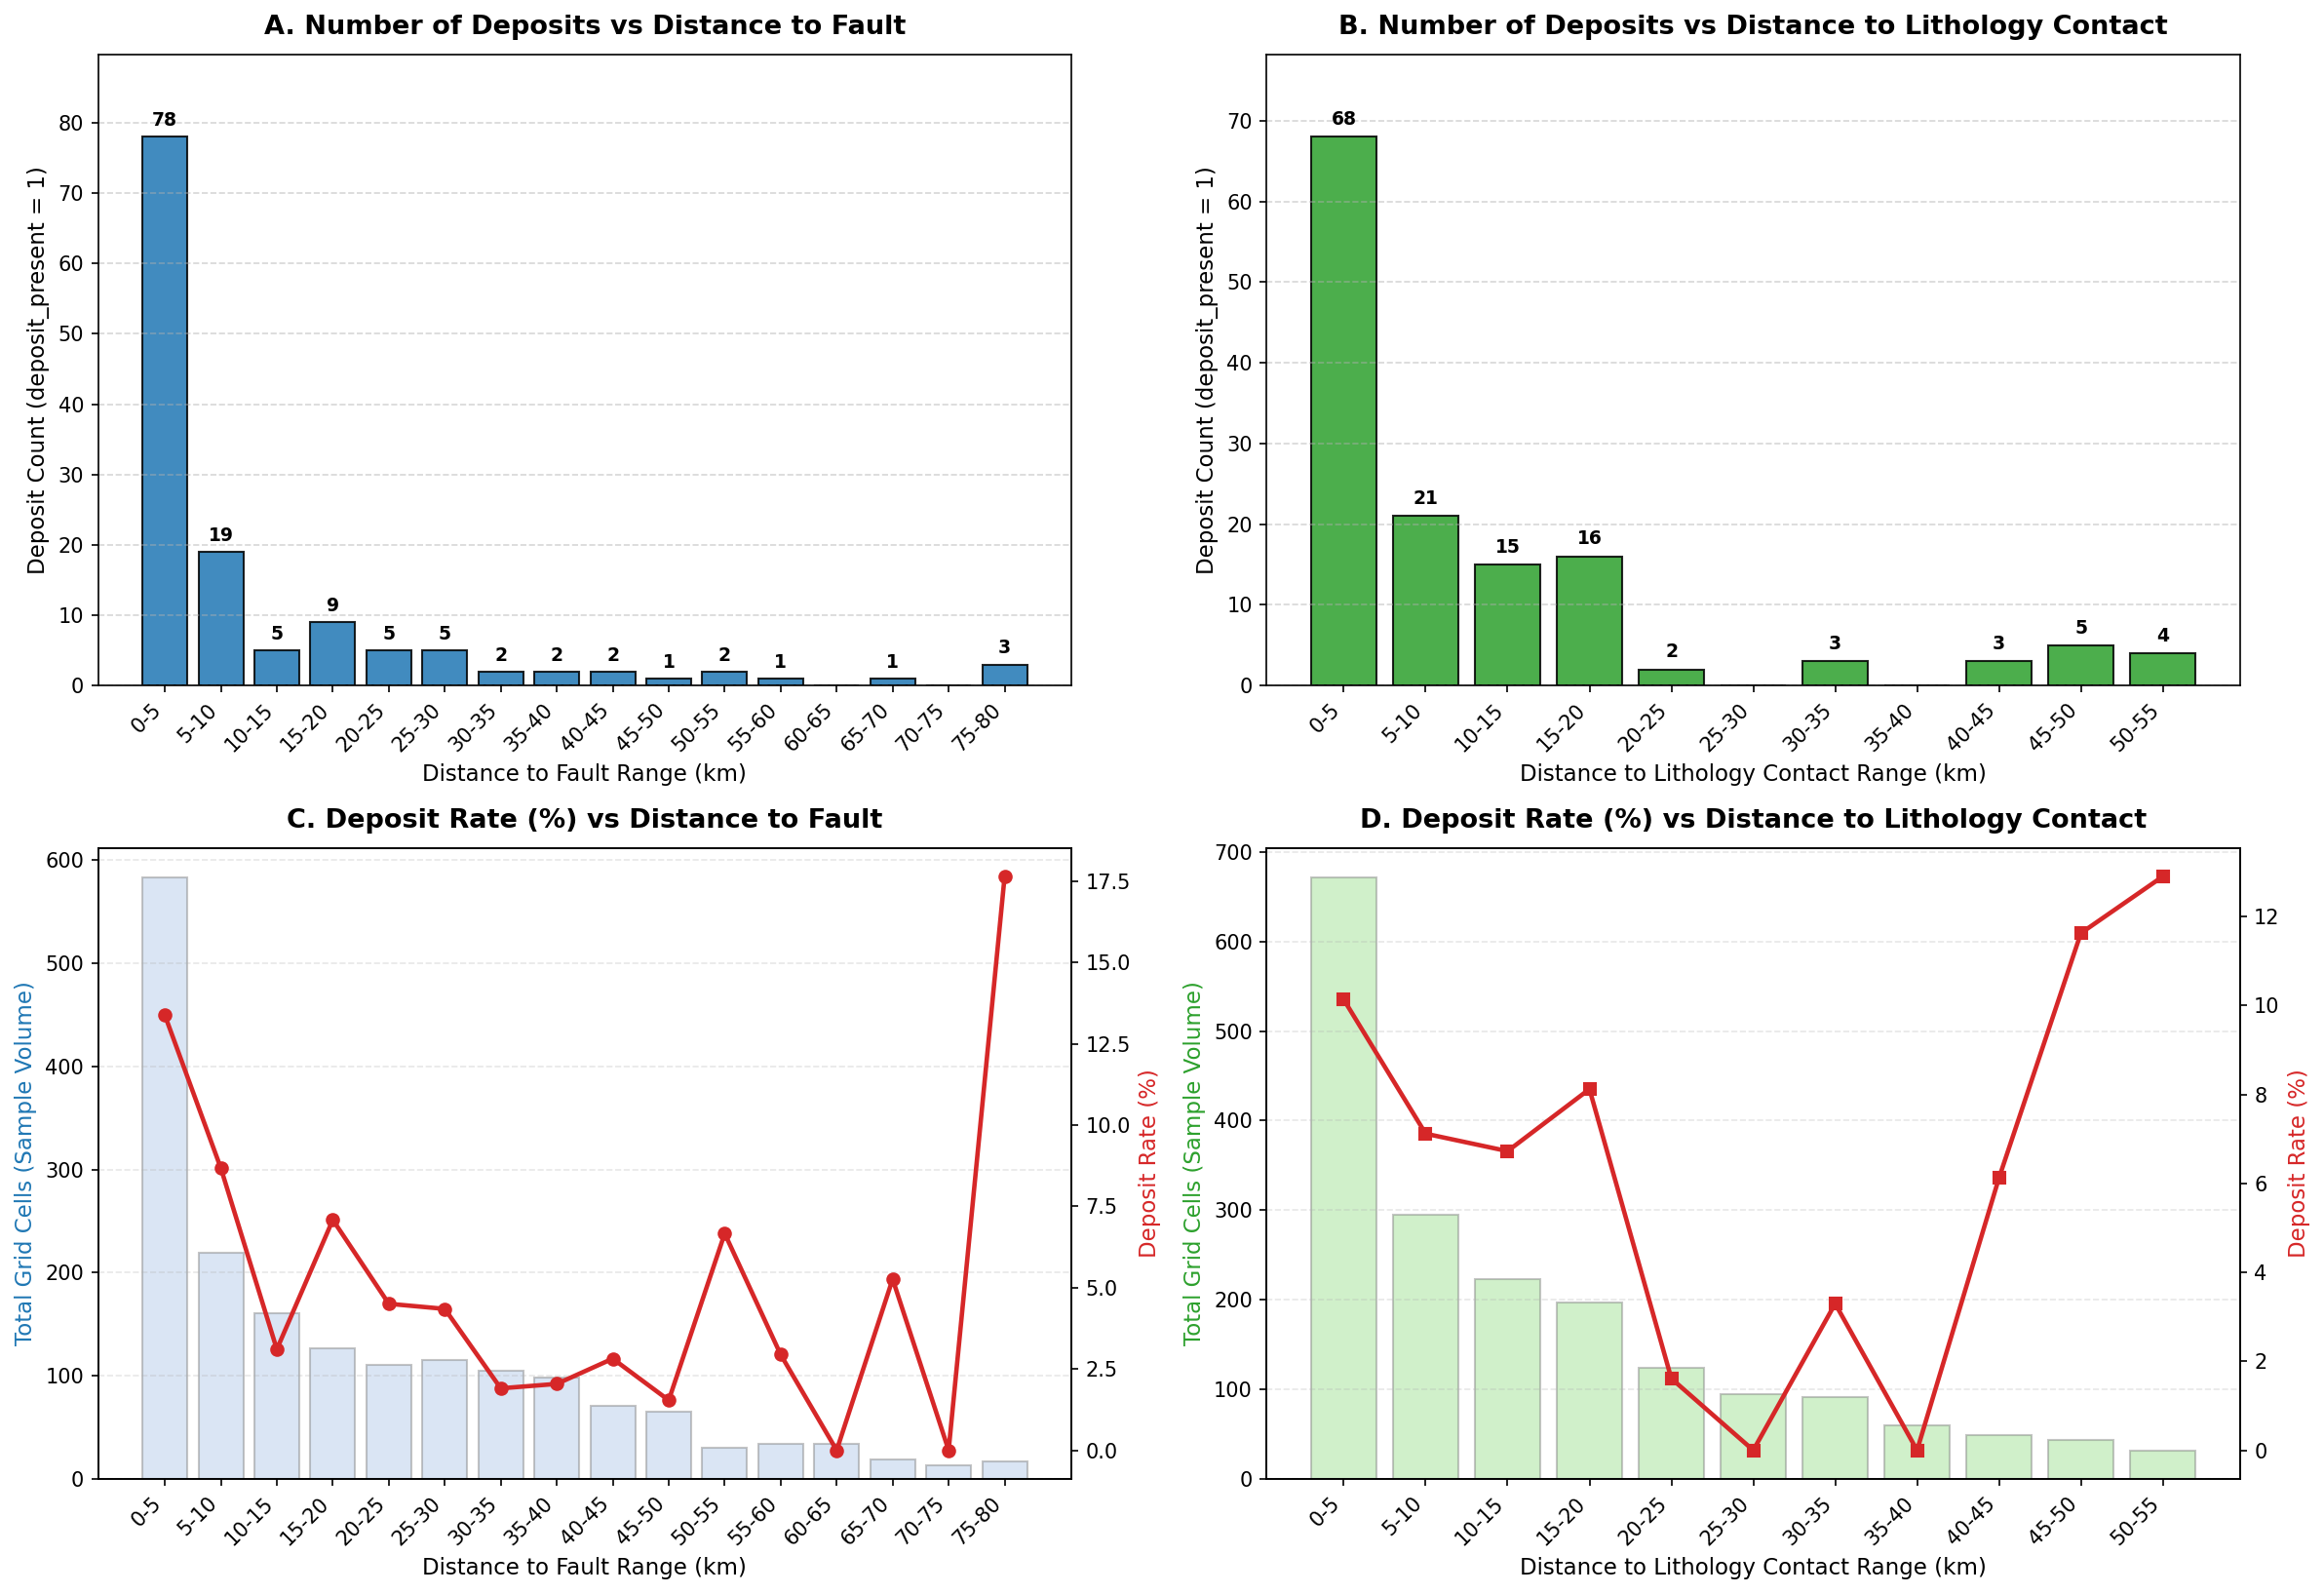

In [13]:
# 4. Plot: Deposits per Range of Distance for Both Distance Predictors
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=150)

# --- Panel A: Deposit Counts vs Distance to Fault ---
bars_f = axes[0, 0].bar(range(len(fault_binned)), fault_binned['deposits'], color='#1f77b4', edgecolor='black', alpha=0.85)
axes[0, 0].set_title('A. Number of Deposits vs Distance to Fault', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Distance to Fault Range (km)', fontsize=11)
axes[0, 0].set_ylabel('Deposit Count (deposit_present = 1)', fontsize=11)
axes[0, 0].set_xticks(range(len(fault_binned)))
axes[0, 0].set_xticklabels(fault_binned['fault_range_km'], rotation=45, ha='right')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0, 0].set_ylim(0, fault_binned['deposits'].max() * 1.15)
for bar in bars_f:
    h = bar.get_height()
    if h > 0:
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Panel B: Deposit Counts vs Distance to Lithology Contact ---
bars_l = axes[0, 1].bar(range(len(lith_binned)), lith_binned['deposits'], color='#2ca02c', edgecolor='black', alpha=0.85)
axes[0, 1].set_title('B. Number of Deposits vs Distance to Lithology Contact', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Distance to Lithology Contact Range (km)', fontsize=11)
axes[0, 1].set_ylabel('Deposit Count (deposit_present = 1)', fontsize=11)
axes[0, 1].set_xticks(range(len(lith_binned)))
axes[0, 1].set_xticklabels(lith_binned['lith_range_km'], rotation=45, ha='right')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes[0, 1].set_ylim(0, lith_binned['deposits'].max() * 1.15)
for bar in bars_l:
    h = bar.get_height()
    if h > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Panel C: Fault Distance Rate (%) and Sample Volume ---
ax_f_rate = axes[1, 0].twinx()
axes[1, 0].bar(range(len(fault_binned)), fault_binned['total_cells'], color='#aec7e8', edgecolor='gray', alpha=0.45, label='Total Cells')
line_f = ax_f_rate.plot(range(len(fault_binned)), fault_binned['deposit_rate_pct'], color='#d62728', marker='o', linewidth=2.2, label='Deposit Rate (%)')
axes[1, 0].set_title('C. Deposit Rate (%) vs Distance to Fault', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Distance to Fault Range (km)', fontsize=11)
axes[1, 0].set_ylabel('Total Grid Cells (Sample Volume)', fontsize=11, color='#1f77b4')
ax_f_rate.set_ylabel('Deposit Rate (%)', fontsize=11, color='#d62728')
axes[1, 0].set_xticks(range(len(fault_binned)))
axes[1, 0].set_xticklabels(fault_binned['fault_range_km'], rotation=45, ha='right')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.3)

# --- Panel D: Lithology Contact Rate (%) and Sample Volume ---
ax_l_rate = axes[1, 1].twinx()
axes[1, 1].bar(range(len(lith_binned)), lith_binned['total_cells'], color='#98df8a', edgecolor='gray', alpha=0.45, label='Total Cells')
line_l = ax_l_rate.plot(range(len(lith_binned)), lith_binned['deposit_rate_pct'], color='#d62728', marker='s', linewidth=2.2, label='Deposit Rate (%)')
axes[1, 1].set_title('D. Deposit Rate (%) vs Distance to Lithology Contact', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Distance to Lithology Contact Range (km)', fontsize=11)
axes[1, 1].set_ylabel('Total Grid Cells (Sample Volume)', fontsize=11, color='#2ca02c')
ax_l_rate.set_ylabel('Deposit Rate (%)', fontsize=11, color='#d62728')
axes[1, 1].set_xticks(range(len(lith_binned)))
axes[1, 1].set_xticklabels(lith_binned['lith_range_km'], rotation=45, ha='right')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

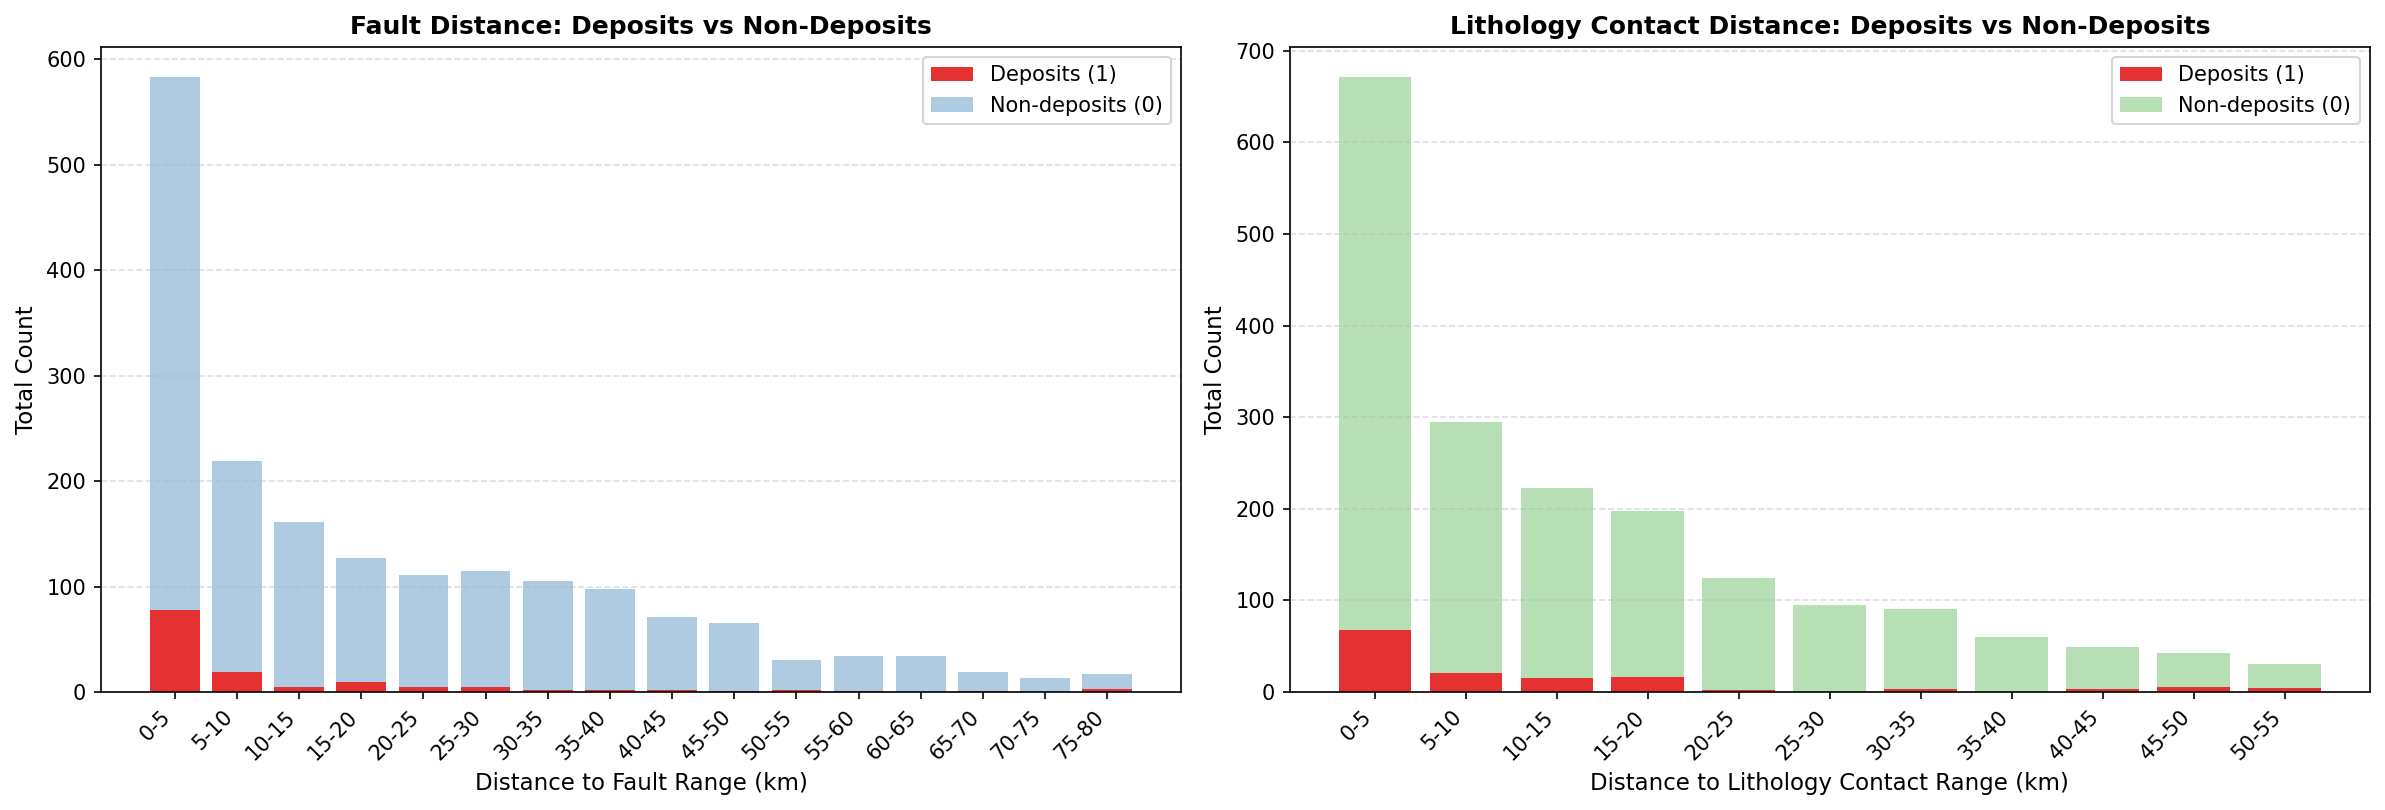

In [14]:
# 5. Direct Side-by-Side Comparison: Deposits vs Non-Deposits Breakdown
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), dpi=150)

# Fault Distance Stacked Breakdown
p1 = axes[0].bar(range(len(fault_binned)), fault_binned['deposits'], color='#e41a1c', label='Deposits (1)', alpha=0.9)
p2 = axes[0].bar(range(len(fault_binned)), fault_binned['non_deposits'], bottom=fault_binned['deposits'], color='#377eb8', label='Non-deposits (0)', alpha=0.4)
axes[0].set_title('Fault Distance: Deposits vs Non-Deposits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Distance to Fault Range (km)', fontsize=11)
axes[0].set_ylabel('Total Count', fontsize=11)
axes[0].set_xticks(range(len(fault_binned)))
axes[0].set_xticklabels(fault_binned['fault_range_km'], rotation=45, ha='right')
axes[0].legend(frameon=True)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Lithology Distance Stacked Breakdown
p3 = axes[1].bar(range(len(lith_binned)), lith_binned['deposits'], color='#e41a1c', label='Deposits (1)', alpha=0.9)
p4 = axes[1].bar(range(len(lith_binned)), lith_binned['non_deposits'], bottom=lith_binned['deposits'], color='#4daf4a', label='Non-deposits (0)', alpha=0.4)
axes[1].set_title('Lithology Contact Distance: Deposits vs Non-Deposits', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Distance to Lithology Contact Range (km)', fontsize=11)
axes[1].set_ylabel('Total Count', fontsize=11)
axes[1].set_xticks(range(len(lith_binned)))
axes[1].set_xticklabels(lith_binned['lith_range_km'], rotation=45, ha='right')
axes[1].legend(frameon=True)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Distance Representation Sensitivity Analysis: Response Curves

The following plots visualize the posterior distance-response curves across the four sensitivity models:
- **Model A**: Raw-Quadratic (Frozen V11 Baseline)
- **Model B**: Log-Quadratic (`log1p(distance_km)`)
- **Model C**: Raw-Linear (`Standardized Raw Distance`, no quadratic terms)
- **Model D**: Log-Linear (`Standardized log(1 + distance)`, no quadratic terms)

Curves are shown across all **6 Daly geological domains**, highlighting empirical support (5th–95th percentiles) and spatial fold stability.

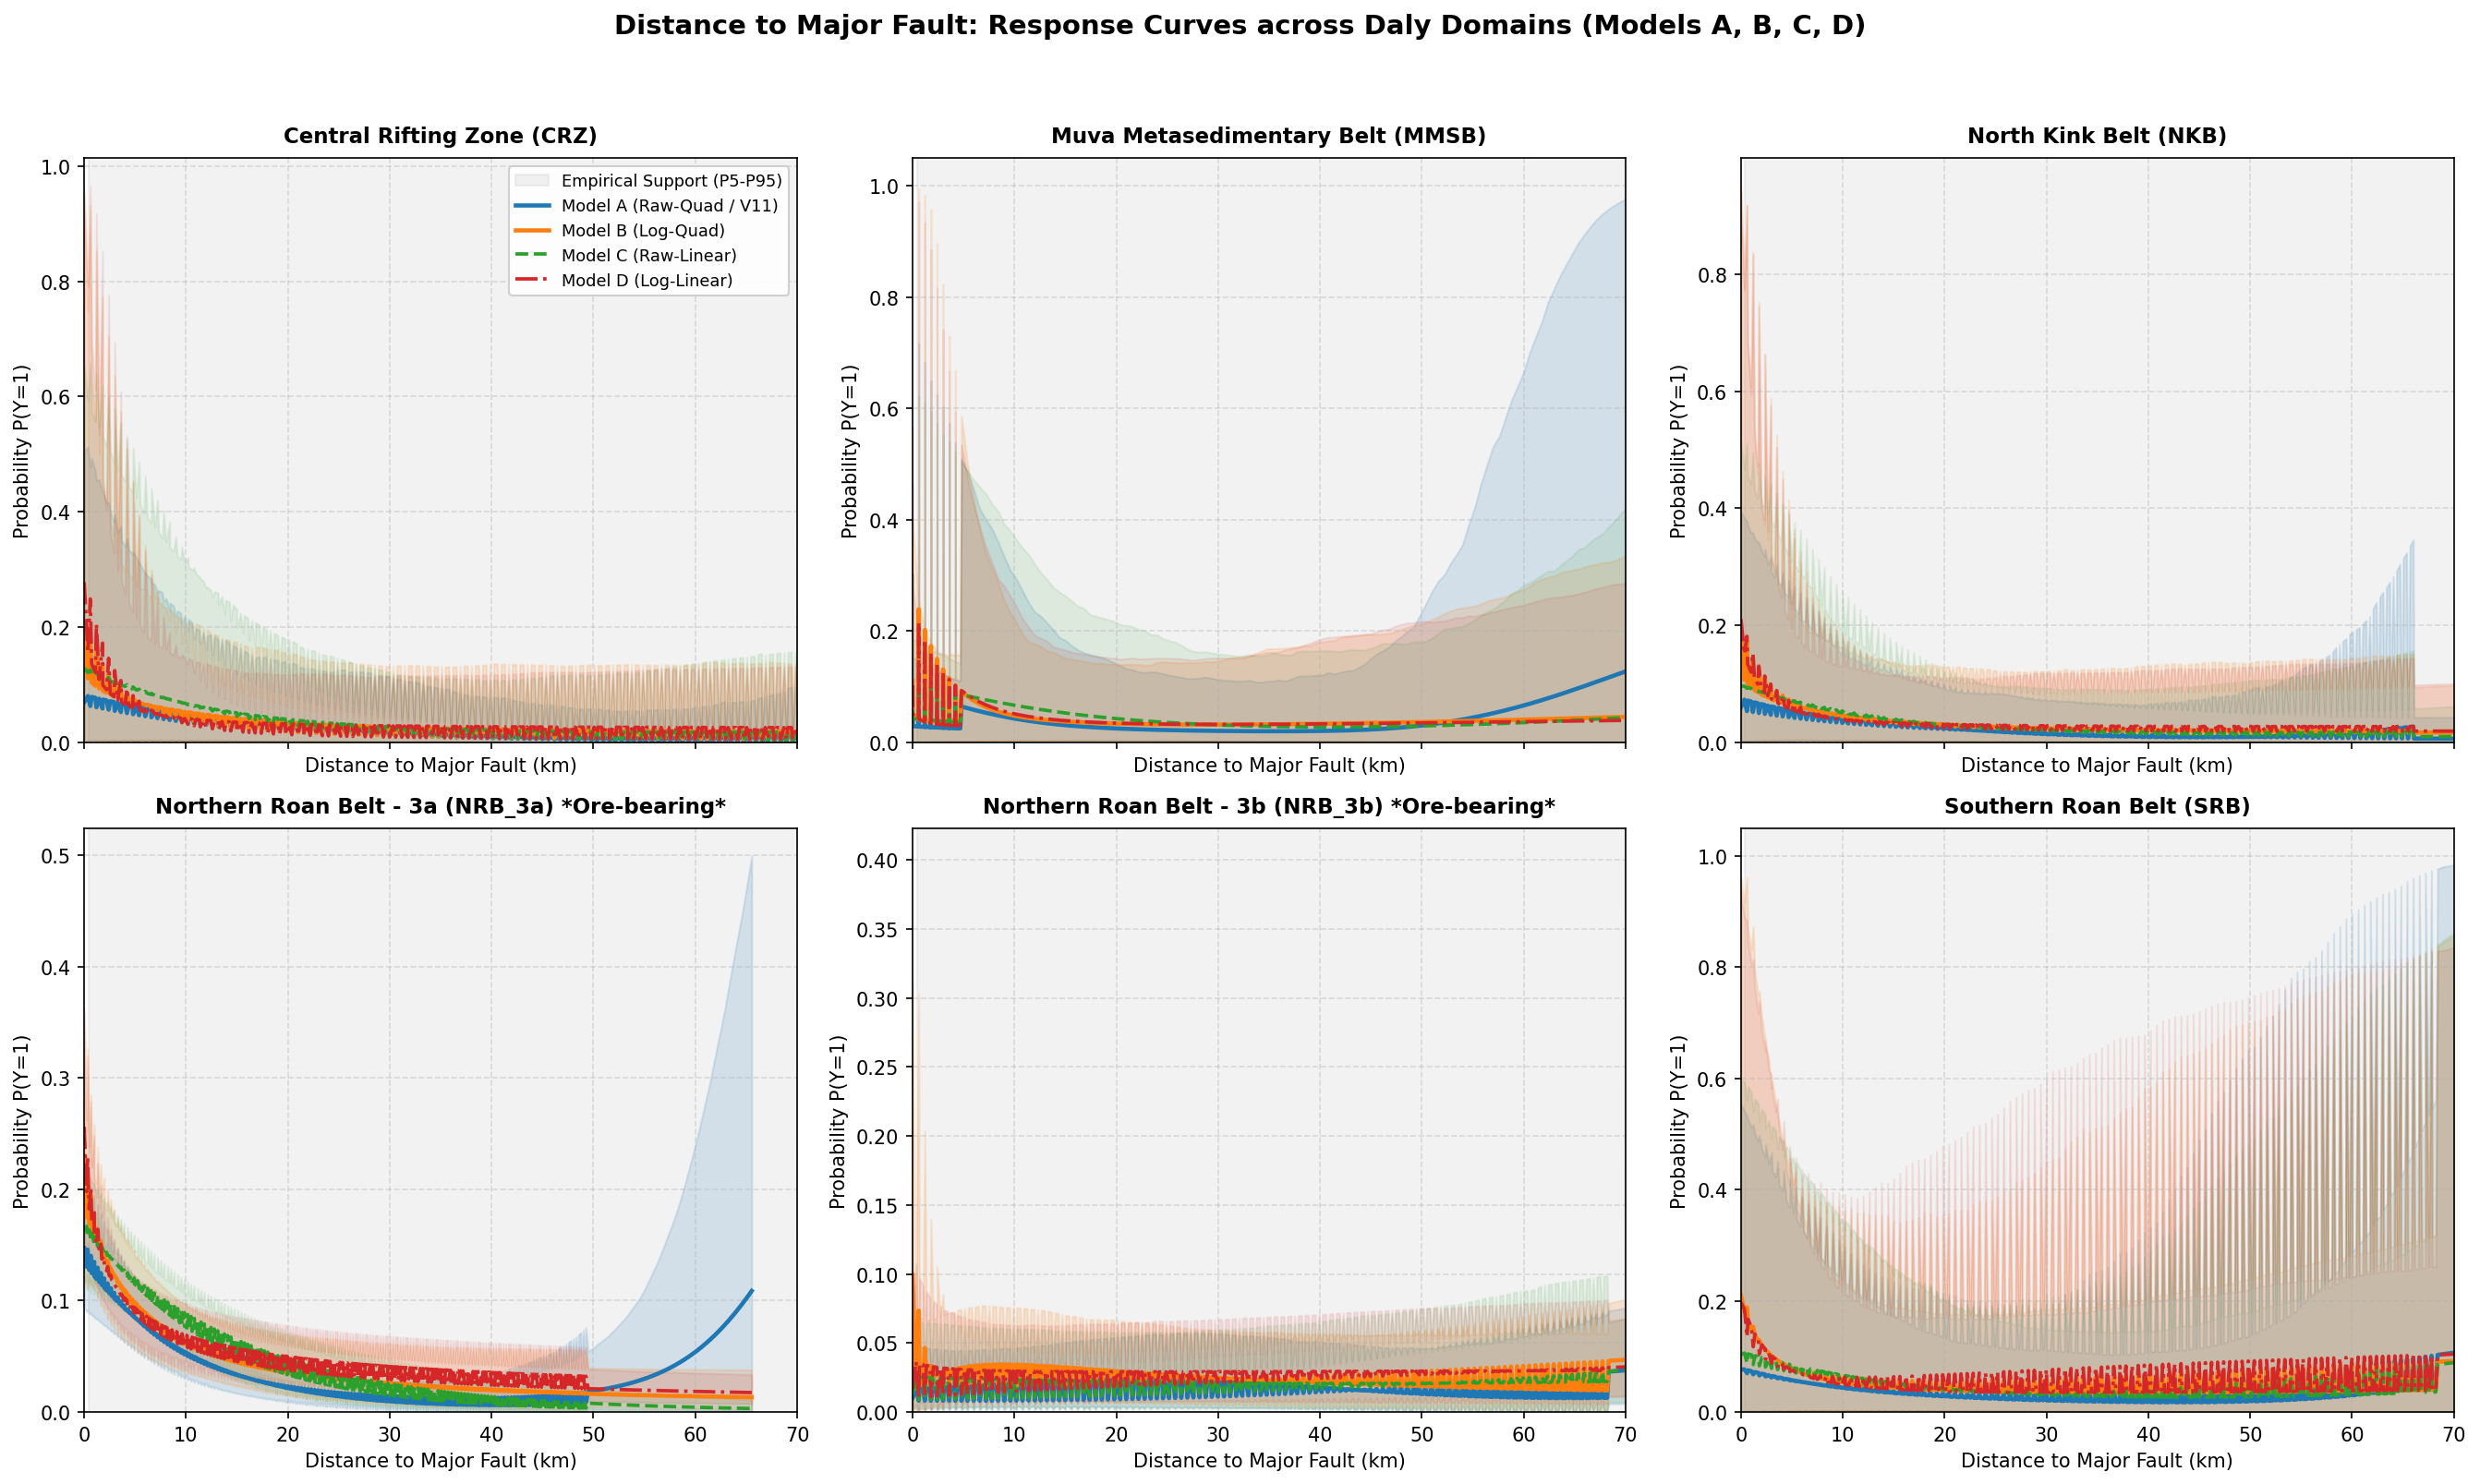

In [15]:
# 1. Plot Distance to Fault Response Curves across Daly Domains
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load response curves and support quantiles
csv_fault = Path("../figures/audit/distance_representation_sensitivity/response_curves_fault.csv")
if not csv_fault.exists():
    csv_fault = Path(r"c:\Users\vanmu\copperbelt-mineral-prospectivity\figures\audit\distance_representation_sensitivity\response_curves_fault.csv")

csv_supp = Path("../figures/audit/distance_representation_sensitivity/support_quantiles.csv")
if not csv_supp.exists():
    csv_supp = Path(r"c:\Users\vanmu\copperbelt-mineral-prospectivity\figures\audit\distance_representation_sensitivity\support_quantiles.csv")

df_fault = pd.read_csv(csv_fault)
df_supp = pd.read_csv(csv_supp) if csv_supp.exists() else None

domains = ['CRZ', 'MMSB', 'NKB', 'NRB_3a', 'NRB_3b', 'SRB']
domain_titles = {
    'CRZ': 'Central Rifting Zone (CRZ)',
    'MMSB': 'Muva Metasedimentary Belt (MMSB)',
    'NKB': 'North Kink Belt (NKB)',
    'NRB_3a': 'Northern Roan Belt - 3a (NRB_3a) *Ore-bearing*',
    'NRB_3b': 'Northern Roan Belt - 3b (NRB_3b) *Ore-bearing*',
    'SRB': 'Southern Roan Belt (SRB)'
}

model_config = {
    'A': {'label': 'Model A (Raw-Quad / V11)', 'color': '#1f77b4', 'ls': '-', 'lw': 2.2, 'alpha': 0.15},
    'B': {'label': 'Model B (Log-Quad)',       'color': '#ff7f0e', 'ls': '-', 'lw': 2.2, 'alpha': 0.15},
    'C': {'label': 'Model C (Raw-Linear)',     'color': '#2ca02c', 'ls': '--', 'lw': 1.8, 'alpha': 0.10},
    'D': {'label': 'Model D (Log-Linear)',     'color': '#d62728', 'ls': '-.', 'lw': 1.8, 'alpha': 0.10}
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11), dpi=150, sharex=True, sharey=False)
axes = axes.flatten()

# Support quantiles for fault
supp_p05 = df_supp[df_supp['predictor'] == 'fault']['p05'].mean() if df_supp is not None else None
supp_p95 = df_supp[df_supp['predictor'] == 'fault']['p95'].mean() if df_supp is not None else None

for i, dom in enumerate(domains):
    ax = axes[i]
    dom_df = df_fault[df_fault['domain'] == dom]
    
    # Shade empirical support window
    if supp_p05 is not None and supp_p95 is not None:
        ax.axvspan(supp_p05, supp_p95, color='gray', alpha=0.10, label='Empirical Support (P5-P95)' if i == 0 else '')
        ax.axvline(supp_p95, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)

    for model_code in ['A', 'B', 'C', 'D']:
        m_df = dom_df[dom_df['model'] == model_code]
        if len(m_df) == 0: continue
        cfg = model_config[model_code]
        
        # Fold mean response and CI ribbon
        grp = m_df.groupby('grid_km').agg({'response_mean': 'mean', 'response_ci_lower': 'mean', 'response_ci_upper': 'mean'}).reset_index()
        ax.plot(grp['grid_km'], grp['response_mean'], label=cfg['label'], color=cfg['color'], linestyle=cfg['ls'], linewidth=cfg['lw'])
        ax.fill_between(grp['grid_km'], grp['response_ci_lower'], grp['response_ci_upper'], color=cfg['color'], alpha=cfg['alpha'])

    ax.set_title(domain_titles[dom], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Distance to Major Fault (km)', fontsize=10)
    ax.set_ylabel('Probability P(Y=1)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, 70)
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

fig.suptitle('Distance to Major Fault: Response Curves across Daly Domains (Models A, B, C, D)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

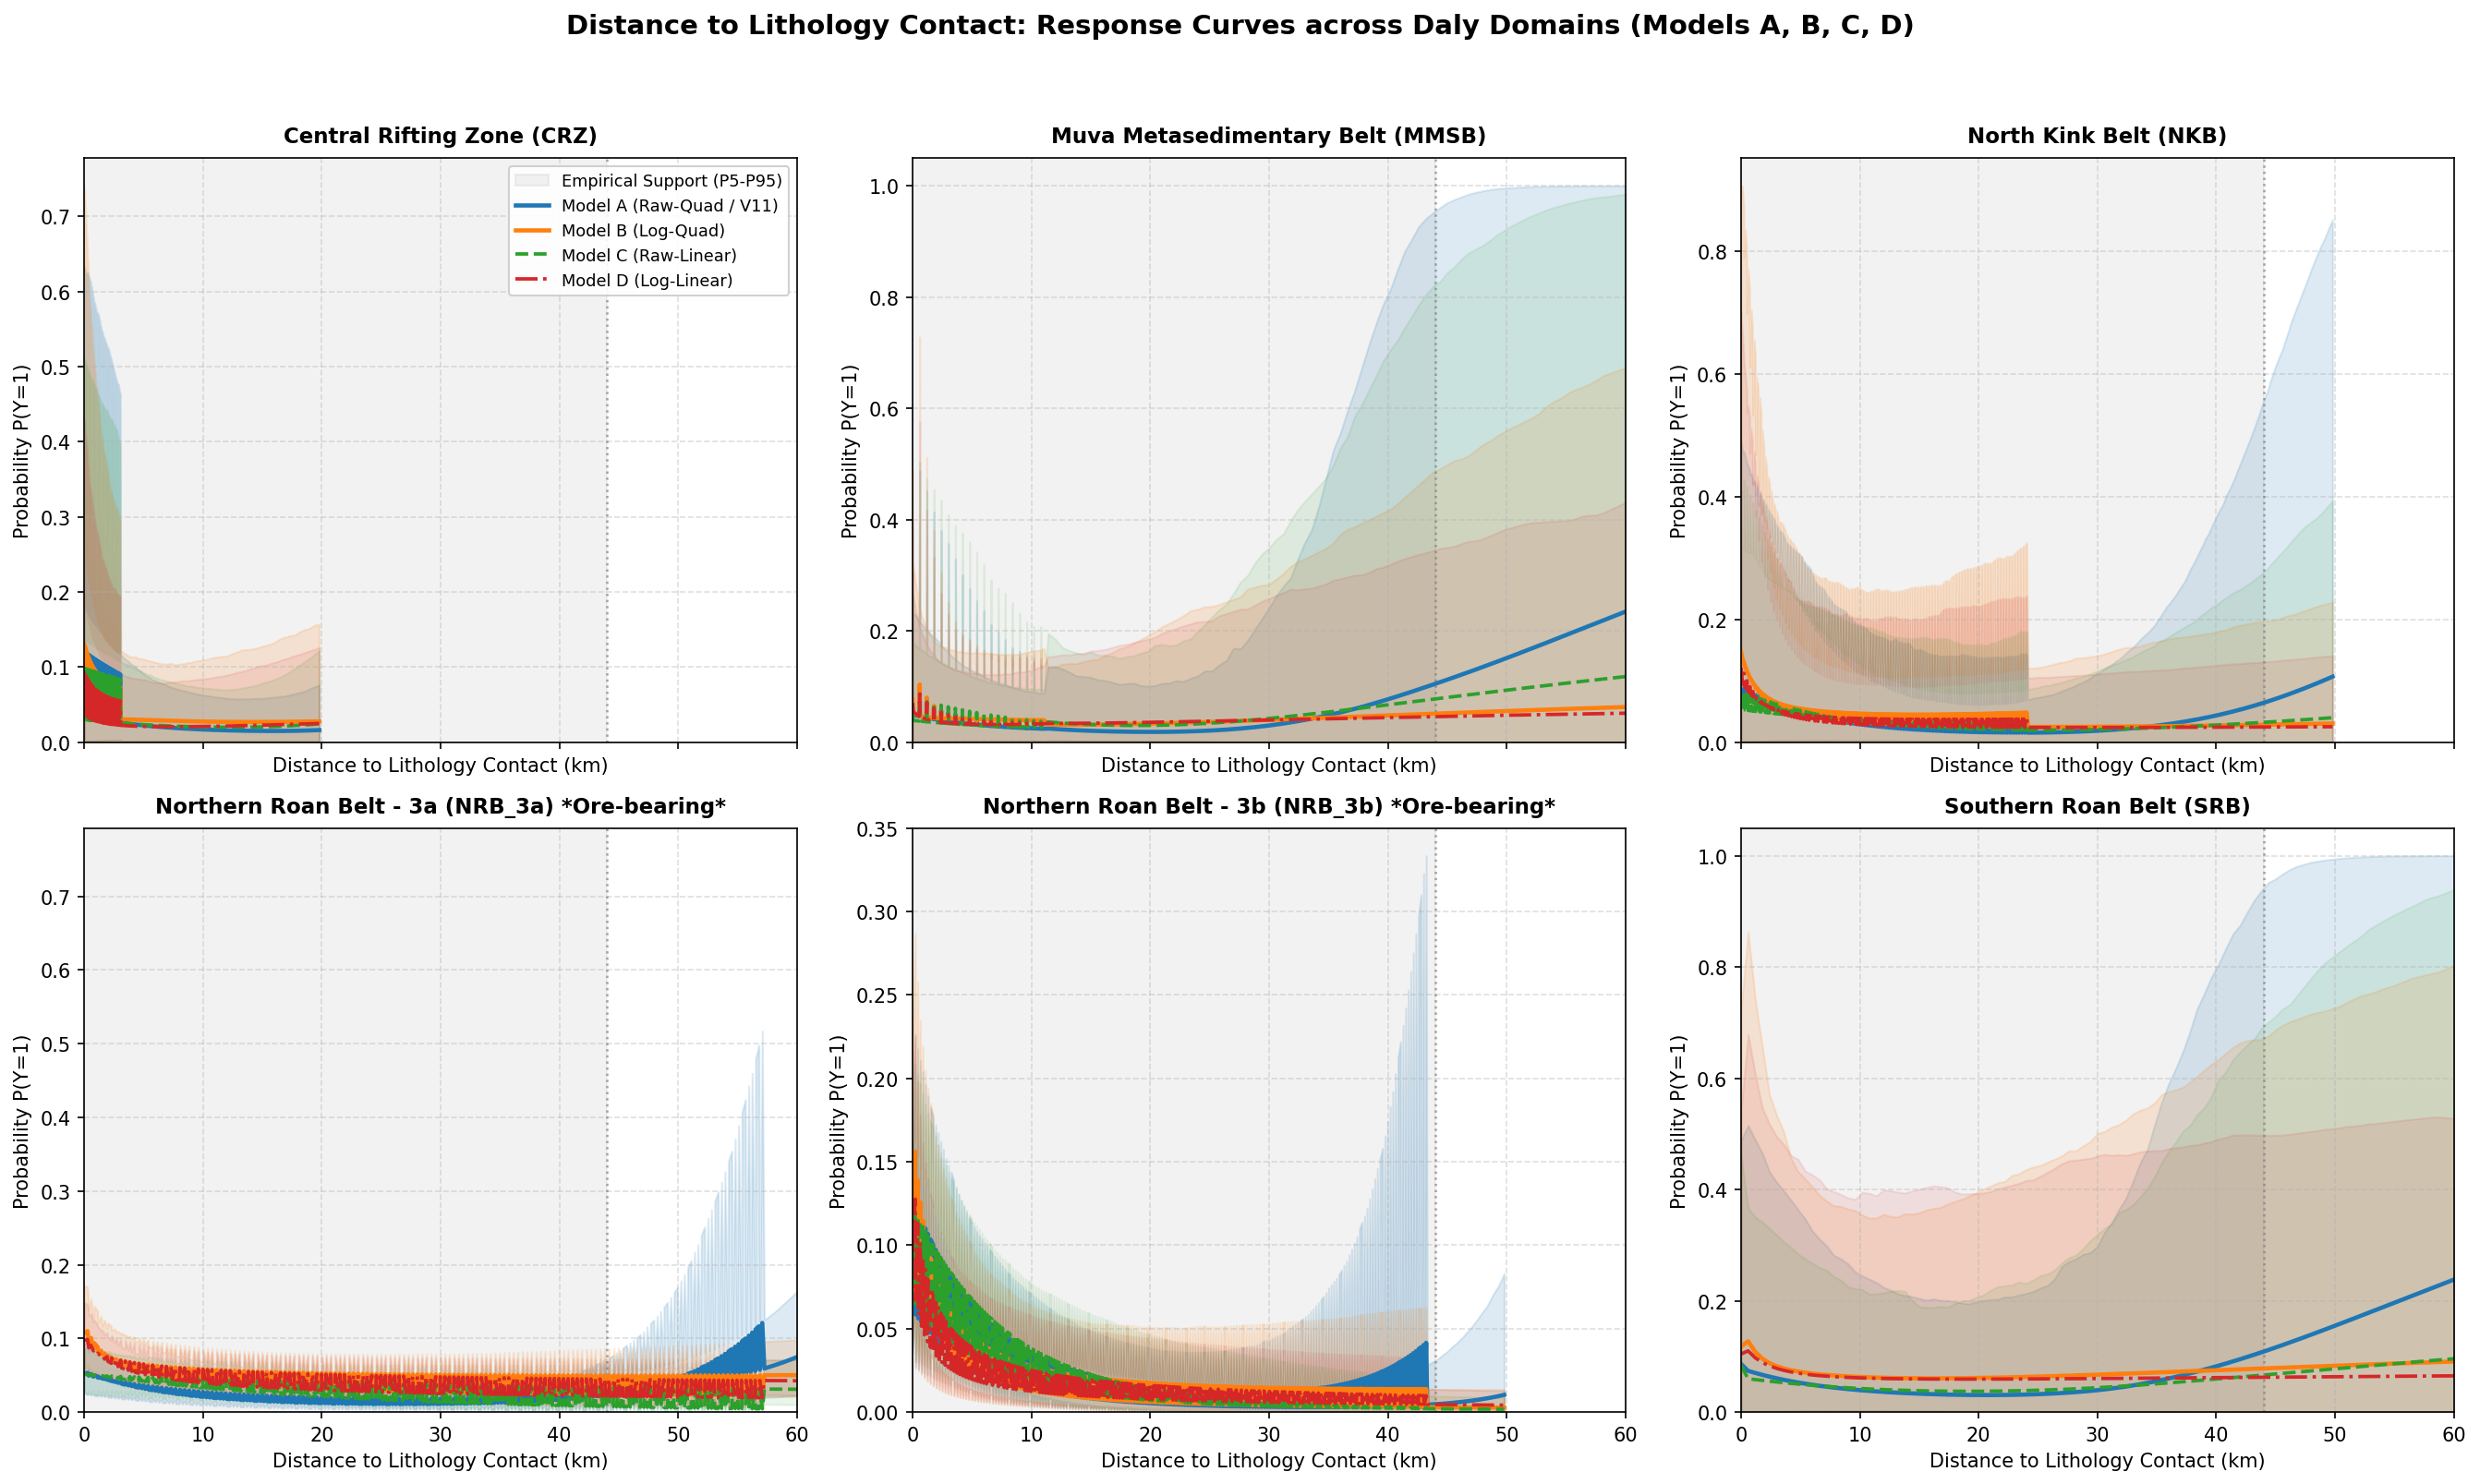

In [16]:
# 2. Plot Distance to Lithological Contact Response Curves across Daly Domains
csv_lith = Path("../figures/audit/distance_representation_sensitivity/response_curves_lithology.csv")
if not csv_lith.exists():
    csv_lith = Path(r"c:\Users\vanmu\copperbelt-mineral-prospectivity\figures\audit\distance_representation_sensitivity\response_curves_lithology.csv")

df_lith = pd.read_csv(csv_lith)

fig, axes = plt.subplots(2, 3, figsize=(18, 11), dpi=150, sharex=True, sharey=False)
axes = axes.flatten()

supp_p05_l = df_supp[df_supp['predictor'] == 'lith']['p05'].mean() if df_supp is not None else None
supp_p95_l = df_supp[df_supp['predictor'] == 'lith']['p95'].mean() if df_supp is not None else None

for i, dom in enumerate(domains):
    ax = axes[i]
    dom_df = df_lith[df_lith['domain'] == dom]
    
    if supp_p05_l is not None and supp_p95_l is not None:
        ax.axvspan(supp_p05_l, supp_p95_l, color='gray', alpha=0.10, label='Empirical Support (P5-P95)' if i == 0 else '')
        ax.axvline(supp_p95_l, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)

    for model_code in ['A', 'B', 'C', 'D']:
        m_df = dom_df[dom_df['model'] == model_code]
        if len(m_df) == 0: continue
        cfg = model_config[model_code]
        
        grp = m_df.groupby('grid_km').agg({'response_mean': 'mean', 'response_ci_lower': 'mean', 'response_ci_upper': 'mean'}).reset_index()
        ax.plot(grp['grid_km'], grp['response_mean'], label=cfg['label'], color=cfg['color'], linestyle=cfg['ls'], linewidth=cfg['lw'])
        ax.fill_between(grp['grid_km'], grp['response_ci_lower'], grp['response_ci_upper'], color=cfg['color'], alpha=cfg['alpha'])

    ax.set_title(domain_titles[dom], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Distance to Lithology Contact (km)', fontsize=10)
    ax.set_ylabel('Probability P(Y=1)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, 60)
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

fig.suptitle('Distance to Lithology Contact: Response Curves across Daly Domains (Models A, B, C, D)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

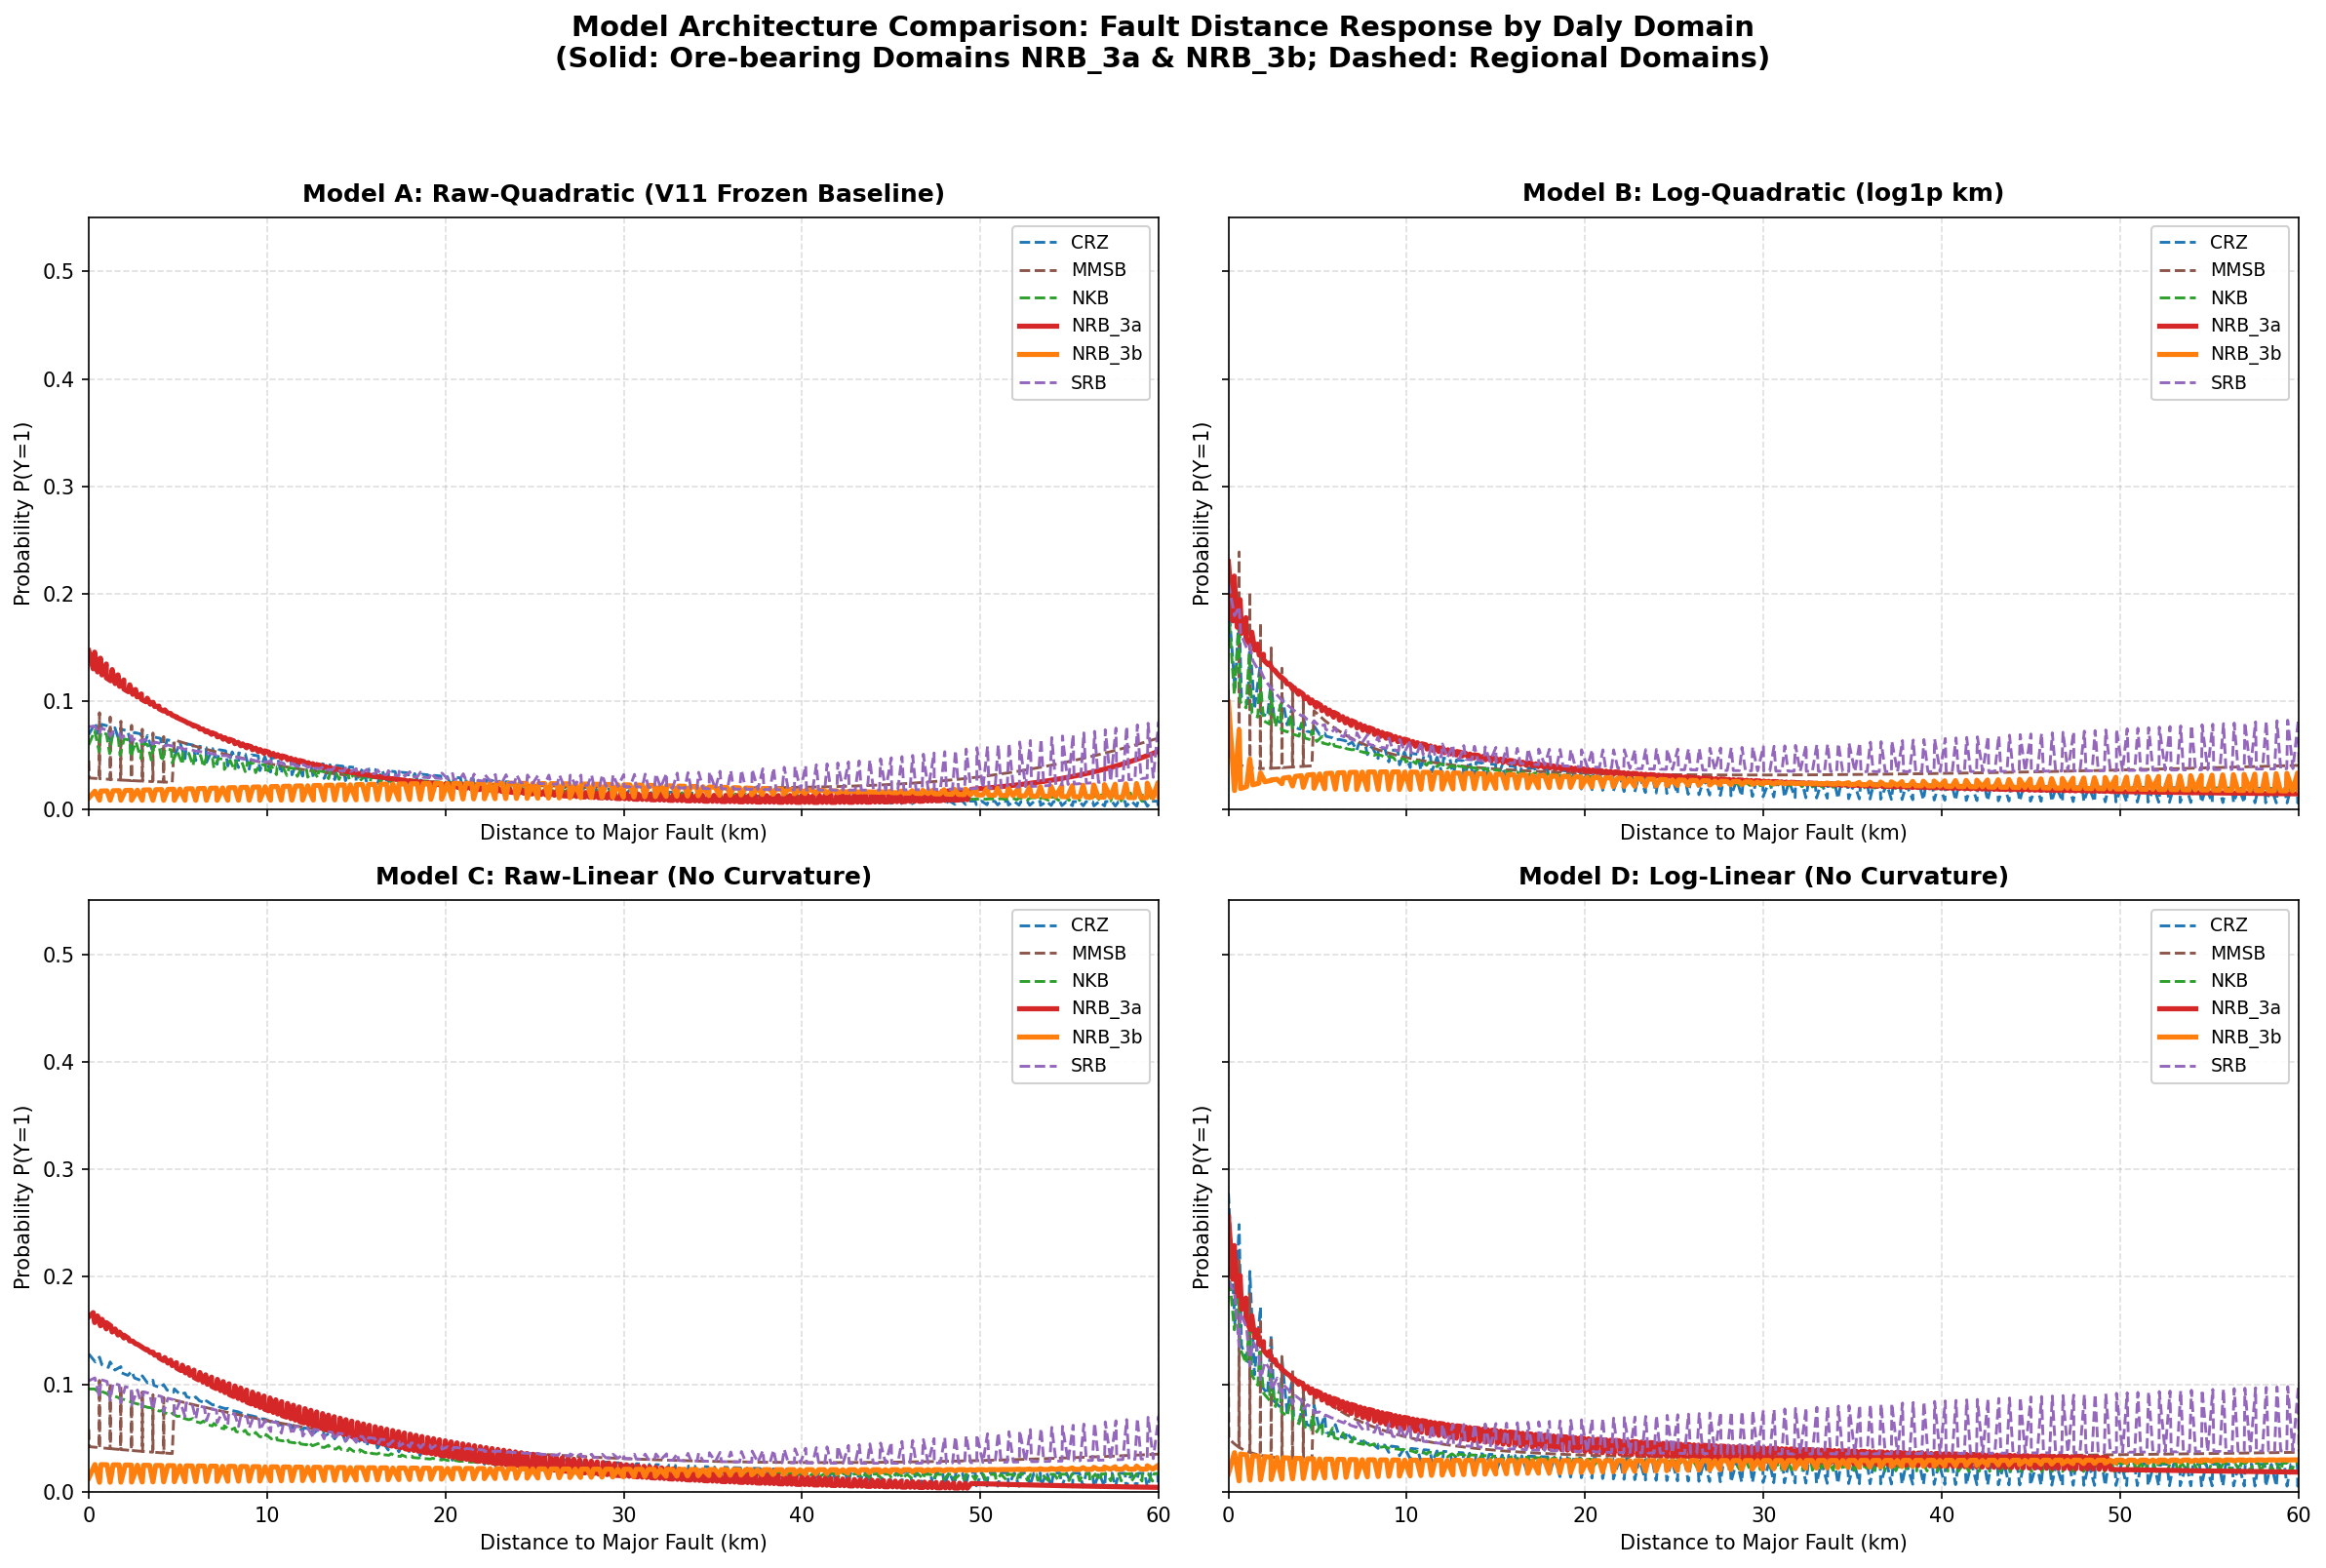

In [17]:
# 3. Model Architecture Matrix (2x2 Grid: Models A, B, C, D)
domain_colors = {
    'NRB_3a': '#d62728', 'NRB_3b': '#ff7f0e', 'CRZ': '#1f77b4',
    'SRB': '#9467bd', 'NKB': '#2ca02c', 'MMSB': '#8c564b'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=150, sharex=True, sharey=True)
model_panels = [
    (axes[0, 0], 'A', 'Model A: Raw-Quadratic (V11 Frozen Baseline)'),
    (axes[0, 1], 'B', 'Model B: Log-Quadratic (log1p km)'),
    (axes[1, 0], 'C', 'Model C: Raw-Linear (No Curvature)'),
    (axes[1, 1], 'D', 'Model D: Log-Linear (No Curvature)')
]

for ax, m_code, title in model_panels:
    m_df = df_fault[df_fault['model'] == m_code]
    for dom in domains:
        dom_df = m_df[m_df['domain'] == dom]
        grp = dom_df.groupby('grid_km')['response_mean'].mean().reset_index()
        is_nrb = 'NRB' in dom
        ax.plot(grp['grid_km'], grp['response_mean'], label=dom,
                color=domain_colors[dom], linewidth=2.5 if is_nrb else 1.4,
                linestyle='-' if is_nrb else '--')
        
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Distance to Major Fault (km)', fontsize=10)
    ax.set_ylabel('Probability P(Y=1)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 0.55)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.suptitle('Model Architecture Comparison: Fault Distance Response by Daly Domain\n(Solid: Ore-bearing Domains NRB_3a & NRB_3b; Dashed: Regional Domains)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

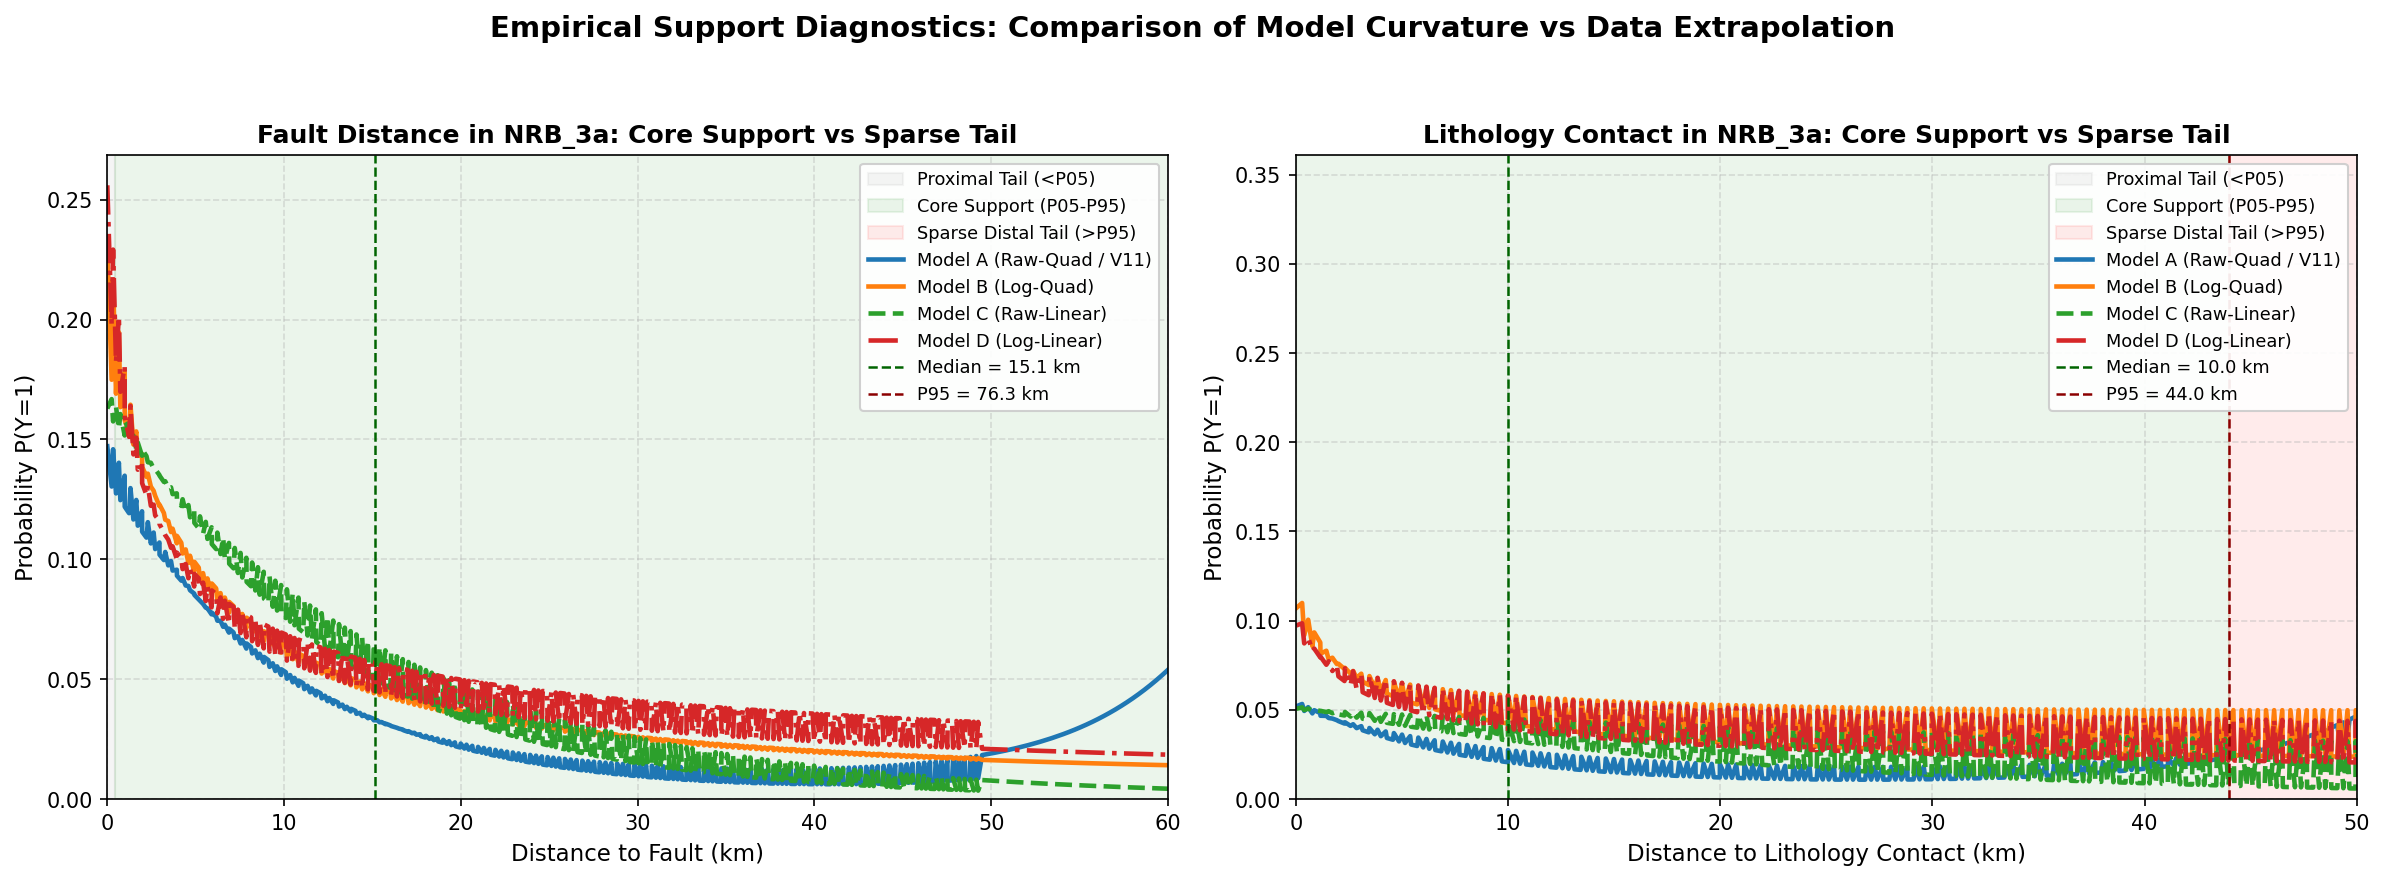

In [18]:
# 4. Empirical Support & Sparse Tail Extrapolation Diagnostic (NRB_3a & NRB_3b)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Left: Fault Distance in NRB_3a
ax = axes[0]
dom_df = df_fault[df_fault['domain'] == 'NRB_3a']
p05_f = df_supp[df_supp['predictor'] == 'fault']['p05'].mean()
p50_f = df_supp[df_supp['predictor'] == 'fault']['p50'].mean()
p95_f = df_supp[df_supp['predictor'] == 'fault']['p95'].mean()

ax.axvspan(0, p05_f, color='gray', alpha=0.08, label='Proximal Tail (<P05)')
ax.axvspan(p05_f, p95_f, color='green', alpha=0.08, label='Core Support (P05-P95)')
ax.axvspan(p95_f, 70, color='red', alpha=0.08, label='Sparse Distal Tail (>P95)')

for m_code in ['A', 'B', 'C', 'D']:
    grp = dom_df[dom_df['model'] == m_code].groupby('grid_km')['response_mean'].mean().reset_index()
    cfg = model_config[m_code]
    ax.plot(grp['grid_km'], grp['response_mean'], label=cfg['label'], color=cfg['color'], linestyle=cfg['ls'], linewidth=2.2)

ax.axvline(p50_f, color='darkgreen', linestyle='--', linewidth=1.2, label=f'Median = {p50_f:.1f} km')
ax.axvline(p95_f, color='darkred', linestyle='--', linewidth=1.2, label=f'P95 = {p95_f:.1f} km')
ax.set_title('Fault Distance in NRB_3a: Core Support vs Sparse Tail', fontsize=12, fontweight='bold')
ax.set_xlabel('Distance to Fault (km)', fontsize=11)
ax.set_ylabel('Probability P(Y=1)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, 60)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.92)

# Right: Lithology Distance in NRB_3a
ax2 = axes[1]
dom_df_l = df_lith[df_lith['domain'] == 'NRB_3a']
p05_l = df_supp[df_supp['predictor'] == 'lith']['p05'].mean()
p50_l = df_supp[df_supp['predictor'] == 'lith']['p50'].mean()
p95_l = df_supp[df_supp['predictor'] == 'lith']['p95'].mean()

ax2.axvspan(0, p05_l, color='gray', alpha=0.08, label='Proximal Tail (<P05)')
ax2.axvspan(p05_l, p95_l, color='green', alpha=0.08, label='Core Support (P05-P95)')
ax2.axvspan(p95_l, 60, color='red', alpha=0.08, label='Sparse Distal Tail (>P95)')

for m_code in ['A', 'B', 'C', 'D']:
    grp = dom_df_l[dom_df_l['model'] == m_code].groupby('grid_km')['response_mean'].mean().reset_index()
    cfg = model_config[m_code]
    ax2.plot(grp['grid_km'], grp['response_mean'], label=cfg['label'], color=cfg['color'], linestyle=cfg['ls'], linewidth=2.2)

ax2.axvline(p50_l, color='darkgreen', linestyle='--', linewidth=1.2, label=f'Median = {p50_l:.1f} km')
ax2.axvline(p95_l, color='darkred', linestyle='--', linewidth=1.2, label=f'P95 = {p95_l:.1f} km')
ax2.set_title('Lithology Contact in NRB_3a: Core Support vs Sparse Tail', fontsize=12, fontweight='bold')
ax2.set_xlabel('Distance to Lithology Contact (km)', fontsize=11)
ax2.set_ylabel('Probability P(Y=1)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_xlim(0, 50)
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper right', fontsize=8.5, framealpha=0.92)

fig.suptitle('Empirical Support Diagnostics: Comparison of Model Curvature vs Data Extrapolation', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()